# Online Retail II — Exploratory Data Analysis

**Dataset:** Online Retail II (UK-based online retailer, transaction line items, Dec 2009–Dec 2011)
**Source:** https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

This notebook follows the structure requested for the exercise: executive summary, data overview, data quality, exploratory analysis, findings, caveats, and next steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Executive Summary

*(Fill this in last, after you've done the analysis below — it should be 4-6 sentences summarizing the most decision-relevant findings, not a recap of every step.)*

## 2. Data Overview

In [9]:
import os
print("cwd:", os.getcwd())
print("data/ exists:", os.path.exists('data'))
print("file exists:", os.path.exists(DATA_PATH))
if os.path.exists('data'):
    print("data/ contents:", os.listdir('data'))

cwd: /home/auser/projects/apurva_synaptiq_hw/exercise_2
data/ exists: True
file exists: True
data/ contents: ['online_retail_II.csv']


In [10]:
# Update this path once you've downloaded the data.
# The Kaggle CSV version typically has a single file; the original UCI version
# is an .xlsx with two sheets ('Year 2009-2010', 'Year 2010-2011').
DATA_PATH = 'data/online_retail_II.csv'  # adjust as needed

if DATA_PATH.endswith('.csv'):
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')
else:
    sheets = pd.read_excel(DATA_PATH, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)

print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [11]:
# Standardize column names (Kaggle version uses 'Customer ID' with a space; normalize to be safe)
df.columns = [c.strip() for c in df.columns]
rename_map = {'Customer ID': 'CustomerID'}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
df.dtypes

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
CustomerID     float64
Country            str
dtype: object

**What is a row?** Each row appears to be a single product line within an invoice — one `StockCode` at one `Quantity`/`Price` on one `InvoiceDate`, tied to an `Invoice` number and (usually) a `CustomerID`. Multiple rows share the same `Invoice` when a customer buys several distinct products in one order. That makes the grain **invoice line item**, not "order" and not "customer" — worth stating explicitly since aggregations later need to roll up correctly (e.g. revenue per *order* requires grouping by `Invoice` first).

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Date range:', df['InvoiceDate'].min(), 'to', df['InvoiceDate'].max())
print('Unique invoices:', df['Invoice'].nunique())
print('Unique customers:', df['CustomerID'].nunique())
print('Unique stock codes:', df['StockCode'].nunique())
print('Unique countries:', df['Country'].nunique())

Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique invoices: 53628
Unique customers: 5942
Unique stock codes: 5305
Unique countries: 43


## 3. Data Quality Checks

In [13]:
# Missing values
missing = df.isna().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
missing.sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
CustomerID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


`CustomerID` and `Description` are the columns most likely to have gaps. A missing `CustomerID` means that transaction can't be attributed to a customer — worth deciding early whether those rows get excluded from customer-level analysis (they should) while still counting toward revenue totals (they still can).

In [14]:
# Exact duplicate rows
dupe_count = df.duplicated().sum()
print(f'Exact duplicate rows: {dupe_count} ({dupe_count/len(df)*100:.2f}%)')
df[df.duplicated(keep=False)].sort_values(['Invoice', 'StockCode']).head(10)

Exact duplicate rows: 34335 (3.22%)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom


In [15]:
# Negative or zero quantities/prices — cancellations, returns, adjustments, or bad data
print('Rows with Quantity <= 0:', (df['Quantity'] <= 0).sum())
print('Rows with Price <= 0:', (df['Price'] <= 0).sum())

# Invoices starting with 'C' are documented as cancellations in this dataset
cancelled = df['Invoice'].astype(str).str.startswith('C')
print('Cancellation invoices (Invoice starts with C):', cancelled.sum())
df.loc[cancelled].head(5)

Rows with Quantity <= 0: 22950
Rows with Price <= 0: 6207
Cancellation invoices (Invoice starts with C): 19494


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia


In [16]:
# Non-product stock codes (postage, fees, adjustments, samples) mixed into the line items
non_numeric_codes = df.loc[~df['StockCode'].astype(str).str.match(r'^\d{5}')]['StockCode'].value_counts().head(15)
non_numeric_codes

StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
Name: count, dtype: int64

In [17]:
# Extreme outliers in quantity and price
print(df[['Quantity', 'Price']].describe())
print()
print('Top 10 largest quantities:')
print(df.nlargest(10, 'Quantity')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'CustomerID']])

          Quantity        Price
count 1,067,371.00 1,067,371.00
mean          9.94         4.65
std         172.71       123.55
min     -80,995.00   -53,594.36
25%           1.00         1.25
50%           3.00         2.10
75%          10.00         4.15
max      80,995.00    38,970.00

Top 10 largest quantities:
        Invoice StockCode                         Description  Quantity  \
1065882  581483     23843         PAPER CRAFT , LITTLE BIRDIE     80995   
587080   541431     23166      MEDIUM CERAMIC TOP STORAGE JAR     74215   
90857    497946     37410  BLACK AND WHITE PAISLEY FLOWER MUG     19152   
127166   501534     21099         SET/6 STRAWBERRY PAPER CUPS     12960   
127168   501534     21091         SET/6 WOODLAND PAPER PLATES     12960   
127169   501534     21085           SET/6 WOODLAND PAPER CUPS     12744   
1027583  578841     84826      ASSTD DESIGN 3D PAPER STICKERS     12540   
127167   501534     21092       SET/6 STRAWBERRY PAPER PLATES     12480   
192197   

**Data quality summary (fill in after running the cells above):**
- Missing `CustomerID`: ~X% of rows — excluded from customer-level cuts, retained for revenue totals
- Duplicates: X exact duplicate rows found — [decision: drop / keep and note]
- Cancellations (`Invoice` starting with 'C'): X rows, representing returns/adjustments — excluded from "sales" analysis, but worth a separate cancellation-rate metric
- Non-product stock codes (POST, DOT, M, etc.): [list what you found] — excluded from product-level analysis
- Outliers: [note anything that looks like a data entry error vs. a legitimate bulk order]

## 4. Exploratory Analysis

In [18]:
# Build a clean transactional view for revenue analysis: valid sales only
sales = df[(df['Quantity'] > 0) & (df['Price'] > 0) & (~cancelled)].copy()
sales['Revenue'] = sales['Quantity'] * sales['Price']
print(f'Clean sales rows: {len(sales):,} of {len(df):,} original rows')
sales['Revenue'].sum()

Clean sales rows: 1,041,670 of 1,067,371 original rows


np.float64(20972594.567999996)

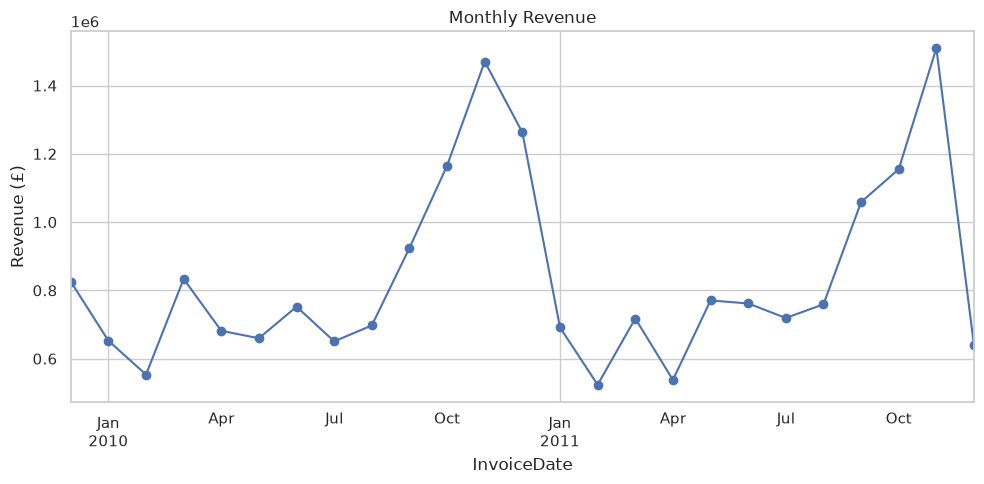

In [19]:
# Revenue trend over time (monthly)
monthly = sales.set_index('InvoiceDate').resample('MS')['Revenue'].sum()
ax = monthly.plot(marker='o')
ax.set_title('Monthly Revenue')
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

In [20]:
# Top products by revenue
top_products = (sales.groupby('Description')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(15))
top_products

Description
REGENCY CAKESTAND 3 TIER              344,563.25
Manual                                340,731.33
DOTCOM POSTAGE                        322,657.48
WHITE HANGING HEART T-LIGHT HOLDER    266,923.55
PAPER CRAFT , LITTLE BIRDIE           168,469.60
JUMBO BAG RED RETROSPOT               150,935.56
PARTY BUNTING                         149,187.05
ASSORTED COLOUR BIRD ORNAMENT         132,187.92
POSTAGE                               127,597.42
PAPER CHAIN KIT 50'S CHRISTMAS        123,141.54
CHILLI LIGHTS                          85,489.91
MEDIUM CERAMIC TOP STORAGE JAR         81,700.92
ROTATING SILVER ANGELS T-LIGHT HLDR    74,448.92
JUMBO BAG STRAWBERRY                   69,565.89
BLACK RECORD COVER FRAME               69,329.47
Name: Revenue, dtype: float64

In [21]:
# Revenue and order concentration by country
by_country = sales.groupby('Country').agg(
    revenue=('Revenue', 'sum'),
    orders=('Invoice', 'nunique'),
    customers=('CustomerID', 'nunique')
).sort_values('revenue', ascending=False)
by_country.head(15)

,revenue,orders,customers
Country,,,
United Kingdom,"17,870,977.78",36535,5350
EIRE,"664,431.78",626,5
Netherlands,"554,232.34",228,22
Germany,"431,262.46",789,107
France,"356,944.60",622,95
Australia,"169,968.11",95,15
Spain,"109,178.53",154,41
Switzerland,"101,011.29",93,22
Sweden,"91,903.72",105,19


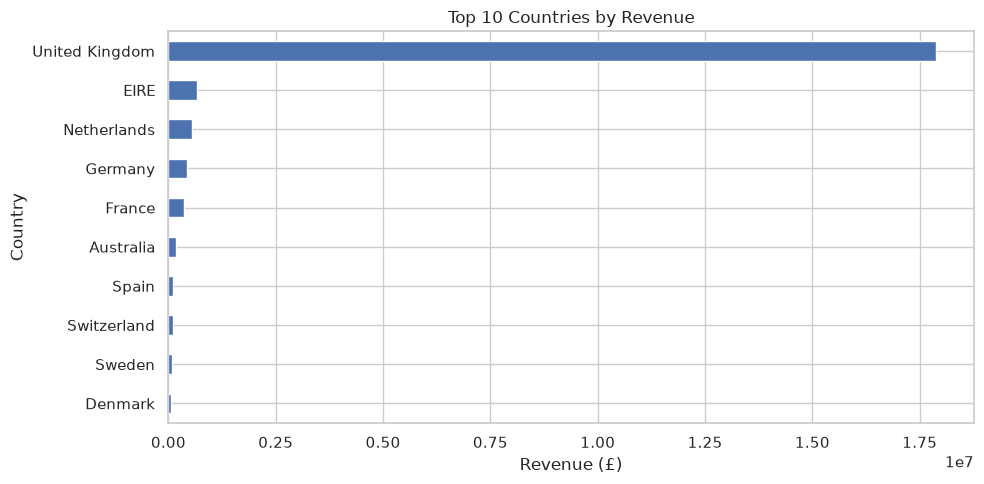

In [22]:
fig, ax = plt.subplots()
by_country.head(10)['revenue'].sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

In [23]:
# Customer-level view: order frequency and spend distribution (basic RFM building blocks)
customer_summary = sales.dropna(subset=['CustomerID']).groupby('CustomerID').agg(
    total_revenue=('Revenue', 'sum'),
    n_orders=('Invoice', 'nunique'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    n_countries=('Country', 'nunique')
)
customer_summary['avg_order_value'] = customer_summary['total_revenue'] / customer_summary['n_orders']
customer_summary.describe()

,total_revenue,n_orders,first_purchase,last_purchase,n_countries,avg_order_value
count,"5,878.00","5,878.00",5878,5878,"5,878.00","5,878.00"
mean,"3,018.62",6.29,2010-08-22 06:57:33.297039,2011-05-22 16:19:59.469207,1.00,391.73
min,2.95,1.00,2009-12-01 07:45:00,2009-12-01 09:55:00,1.00,2.95
25%,348.76,1.00,2010-02-09 14:01:15,2010-11-25 10:24:45,1.00,181.65
50%,898.91,3.00,2010-06-27 13:31:30,2011-09-05 11:59:00,1.00,285.07
75%,"2,307.09",7.00,2011-01-30 14:30:15,2011-11-14 11:31:15,1.00,420.57
max,"608,821.65",398.00,2011-12-09 12:16:00,2011-12-09 12:50:00,2.00,"84,236.25"
std,"14,737.73",13.01,NaN,NaN,0.05,"1,215.07"


Top 10% of customers (587) generate 63.9% of revenue


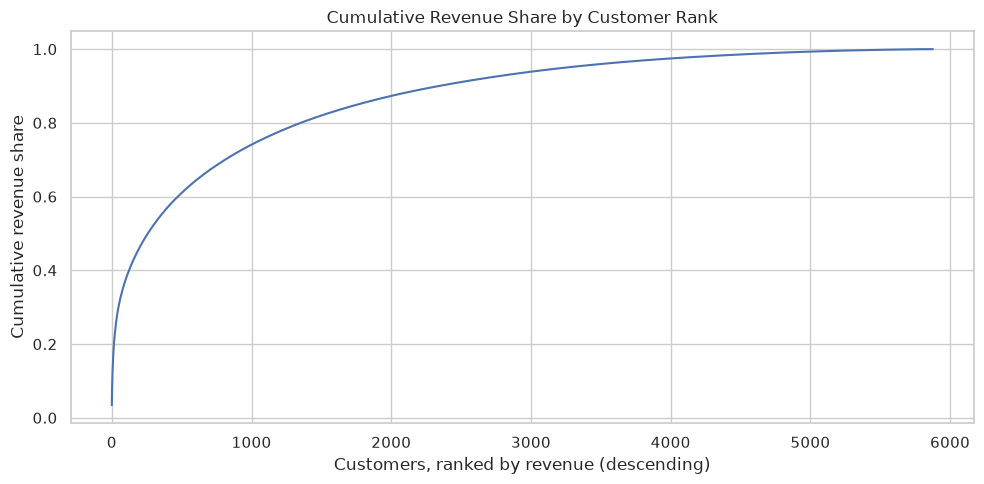

In [24]:
# How concentrated is revenue among top customers? (Pareto check)
sorted_rev = customer_summary['total_revenue'].sort_values(ascending=False)
cum_share = sorted_rev.cumsum() / sorted_rev.sum()
top_10pct_cutoff = int(len(sorted_rev) * 0.10)
print(f"Top 10% of customers ({top_10pct_cutoff}) generate {cum_share.iloc[top_10pct_cutoff]*100:.1f}% of revenue")

fig, ax = plt.subplots()
cum_share.reset_index(drop=True).plot(ax=ax)
ax.set_title('Cumulative Revenue Share by Customer Rank')
ax.set_xlabel('Customers, ranked by revenue (descending)')
ax.set_ylabel('Cumulative revenue share')
plt.tight_layout()
plt.show()

In [ ]:
# One-time vs. repeat customers
repeat_share = (customer_summary['n_orders'] > 1).mean()
print(f'Share of customers with more than one order: {repeat_share*100:.1f}%')

## 5. Findings and Hypotheses

*(Write 3–5 here after reviewing the charts/tables above. For each: state the finding, why it matters commercially, and your confidence level with a one-line reason — e.g. "high confidence, large sample and consistent across months" vs. "low confidence, driven by a handful of large orders from one customer.")*

1. **Finding:** ...
   **Why it matters:** ...
   **Confidence:** ...

2. **Finding:** ...

3. **Finding:** ...

## 6. Caveats

*(What could be misleading, uncertain, or incomplete? Consider: the ~X% of rows with no CustomerID and what that does to customer-level stats; whether cancellations were handled consistently; single-country dominance skewing "global" patterns; the dataset spanning a fixed historical window with no way to know if it's representative of current behavior; any manual judgment calls made in the data quality step above.)*

## 7. Recommended Next Steps

*(If this were a real client engagement — what would you actually do next? E.g. validate the CustomerID-missing rows with the source system, build a proper RFM/cohort analysis, segment by country and category, check for seasonality vs. one-off promotional spikes, etc.)*

## 8. Use of GenAI

*(Describe concretely: what you asked it to help with — e.g. scaffolding the notebook structure, suggesting data quality checks, drafting chart code — what you changed or rejected, and how you verified the outputs against the actual data rather than taking them on faith.)*